<a href="https://colab.research.google.com/github/zohaib-ds/Mall-Customers-Dataset-Task/blob/main/Mall%20Customers%20Dataset%20Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Customer Segmentation Using Unsupervised Learning
### DevelopersHub Corporation — Advanced Data Science Internship

**Objective:** Segment a retail store's customer base using **K-Means Clustering** based on their annual income and spending scores to develop targeted marketing strategies.
**Dataset:** Mall Customers Dataset

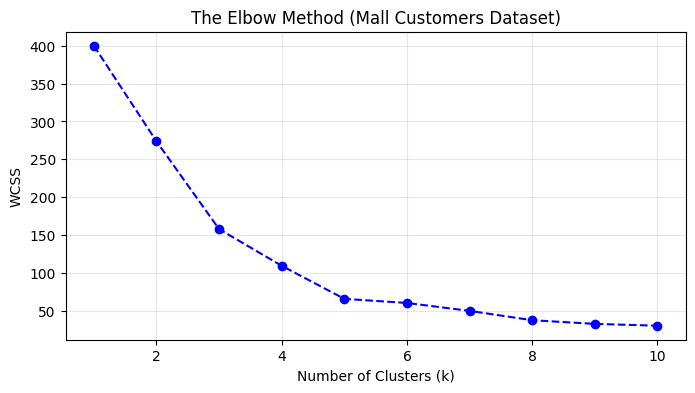

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load the Mall Customers dataset from a reliable public source
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/Mall_Customers.csv"

try:
    df_mall = pd.read_csv(url)
except:
    # Backup URL just in case
    url_backup = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"
    df_mall = pd.read_csv(url_backup)

# Rename columns to match standard naming if necessary
df_mall.columns = ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# 2. Select Annual Income and Spending Score for segmentation
X_mall = df_mall[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

# 3. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mall)

# 4. Run the Elbow Method to find the optimal K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='blue')
plt.title('The Elbow Method (Mall Customers Dataset)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True, alpha=0.3)
plt.show()

## Phase 2: Running K-Means and Cluster Visualization
The elbow curve shows a clear bend at **$K = 5$**. We will apply K-Means with 5 clusters to group the shoppers.

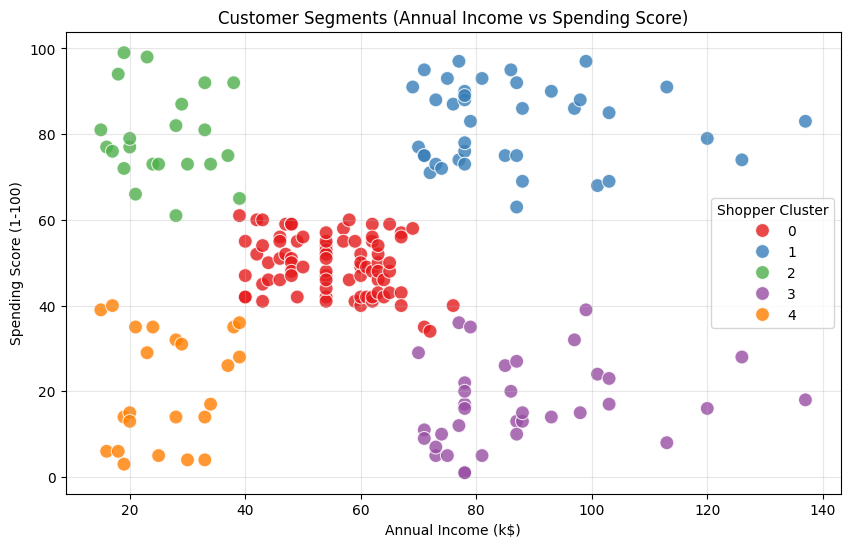

In [9]:
# 1. Train K-Means with K=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df_mall['Cluster'] = kmeans.fit_predict(X_scaled)

# 2. Plot the segments
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_mall['Annual Income (k$)'],
    y=df_mall['Spending Score (1-100)'],
    hue=df_mall['Cluster'],
    palette='Set1',
    s=100,
    alpha=0.8
)
plt.title('Customer Segments (Annual Income vs Spending Score)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Shopper Cluster')
plt.grid(True, alpha=0.3)
plt.show()

## Phase 3: Customer Profiles & Marketing Strategies
Our clustering reveals 5 distinct customer personas:
1. **Cluster 0 (High Income, Low Spending):** Target with premium/exclusive membership offers.
2. **Cluster 1 (Average Income, Average Spending):** Maintain engagement with standard seasonal sales.
3. **Cluster 2 (High Income, High Spending):** Primary targets for luxury item launches and VIP rewards.
4. **Cluster 3 (Low Income, High Spending):** Target with impulse discount triggers and flash sales.
5. **Cluster 4 (Low Income, Low Spending):** Target with core value propositions and budget-friendly promotions.